In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('SQLite.csv')


print(df.shape)
df.head()

(22, 3)


,month,total_orders,total_revenue
0,2016-10,265,46566.71
1,2016-12,1,19.62
2,2017-01,750,127545.67
3,2017-02,1653,271298.65
4,2017-03,2546,414369.39


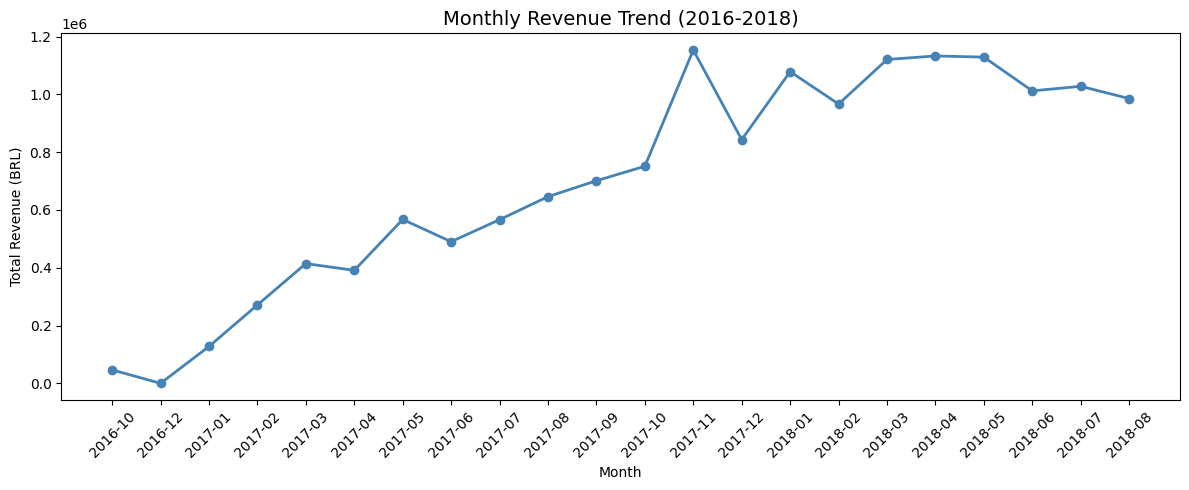

In [6]:

plt.figure(figsize=(12, 5))

plt.plot(df['month'], df['total_revenue'],
         color='steelblue', linewidth=2, marker='o')

plt.title('Monthly Revenue Trend (2016-2018)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

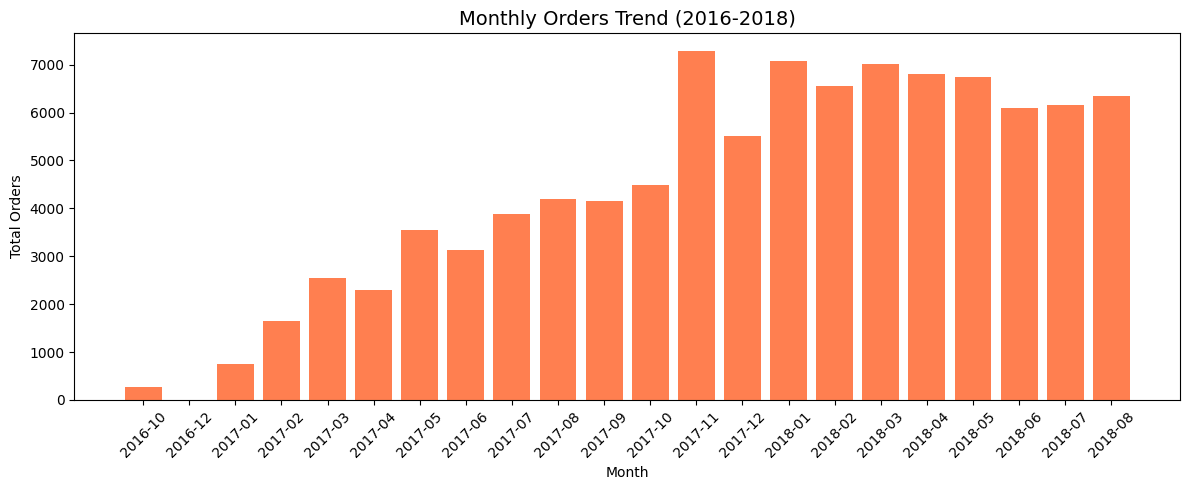

In [8]:

plt.figure(figsize=(12, 5))

plt.bar(df['month'], df['total_orders'], color='coral')

plt.title('Monthly Orders Trend (2016-2018)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:

df['avg_order_value'] = df['total_revenue'] / df['total_orders']
print(df[['month', 'total_orders', 'total_revenue', 'avg_order_value']])

      month  total_orders  total_revenue  avg_order_value
0   2016-10           265       46566.71       175.723434
1   2016-12             1          19.62        19.620000
2   2017-01           750      127545.67       170.060893
3   2017-02          1653      271298.65       164.125015
4   2017-03          2546      414369.39       162.753099
5   2017-04          2303      390952.18       169.757785
6   2017-05          3546      567066.73       159.917296
7   2017-06          3135      490225.60       156.371802
8   2017-07          3872      566403.93       146.282007
9   2017-08          4193      646000.61       154.066446
10  2017-09          4150      701169.99       168.956624
11  2017-10          4478      751140.27       167.740123
12  2017-11          7289     1153528.05       158.256009
13  2017-12          5513      843199.17       152.947428
14  2018-01          7069     1078606.86       152.582665
15  2018-02          6555      966510.88       147.446359
16  2018-03   

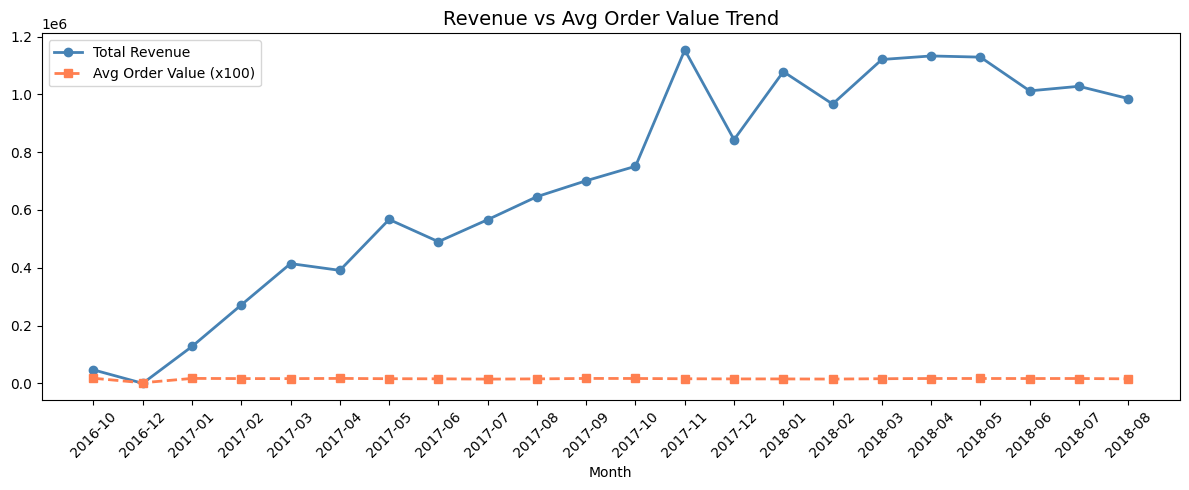

Chart saved!


In [10]:

plt.figure(figsize=(12, 5))
plt.plot(df['month'], df['total_revenue'],
         color='steelblue', linewidth=2, marker='o')
plt.plot(df['month'], df['avg_order_value'] * 100,
         color='coral', linewidth=2, marker='s', linestyle='--')
plt.title('Revenue vs Avg Order Value Trend', fontsize=14)
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(['Total Revenue', 'Avg Order Value (x100)'])
plt.tight_layout()
plt.savefig('story1_revenue_trend.png', dpi=150)
plt.show()
print("Chart saved!")

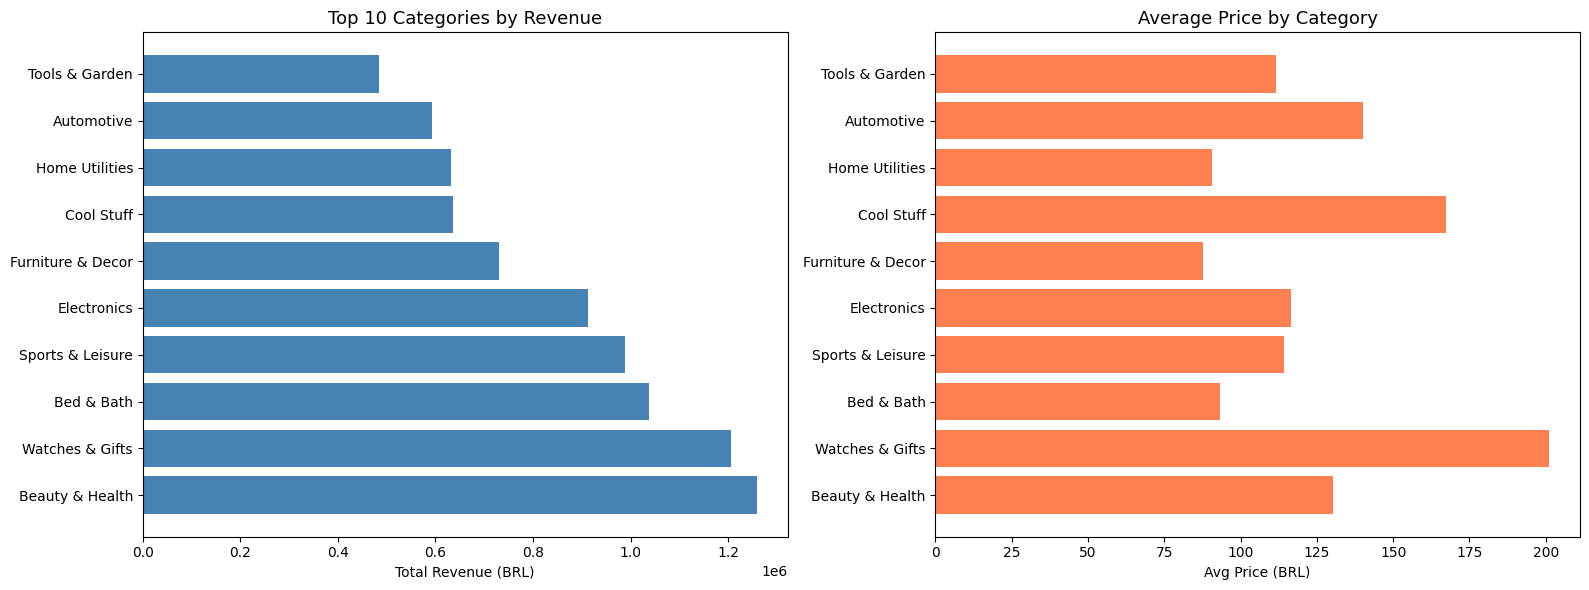

Chart saved!


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df2 = pd.read_csv('order category wise revenue.csv')
translation = {
    'beleza_saude': 'Beauty & Health',
    'relogios_presentes': 'Watches & Gifts',
    'cama_mesa_banho': 'Bed & Bath',
    'esporte_lazer': 'Sports & Leisure',
    'informatica_acessorios': 'Electronics',
    'moveis_decoracao': 'Furniture & Decor',
    'cool_stuff': 'Cool Stuff',
    'utilidades_domesticas': 'Home Utilities',
    'automotivo': 'Automotive',
    'ferramentas_jardim': 'Tools & Garden'
}

df2['category_en'] = df2['product_category'].map(translation)

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Revenue bar chart
ax1.barh(df2['category_en'], df2['total_revenue'], color='steelblue')
ax1.set_title('Top 10 Categories by Revenue', fontsize=13)
ax1.set_xlabel('Total Revenue (BRL)')

# Right: Avg price bar chart
ax2.barh(df2['category_en'], df2['avg_price'], color='coral')
ax2.set_title('Average Price by Category', fontsize=13)
ax2.set_xlabel('Avg Price (BRL)')

plt.tight_layout()
plt.savefig('story2_categories.png', dpi=150)
plt.show()
print("Chart saved!")


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df3 = pd.read_csv('Delivery performance.csv')



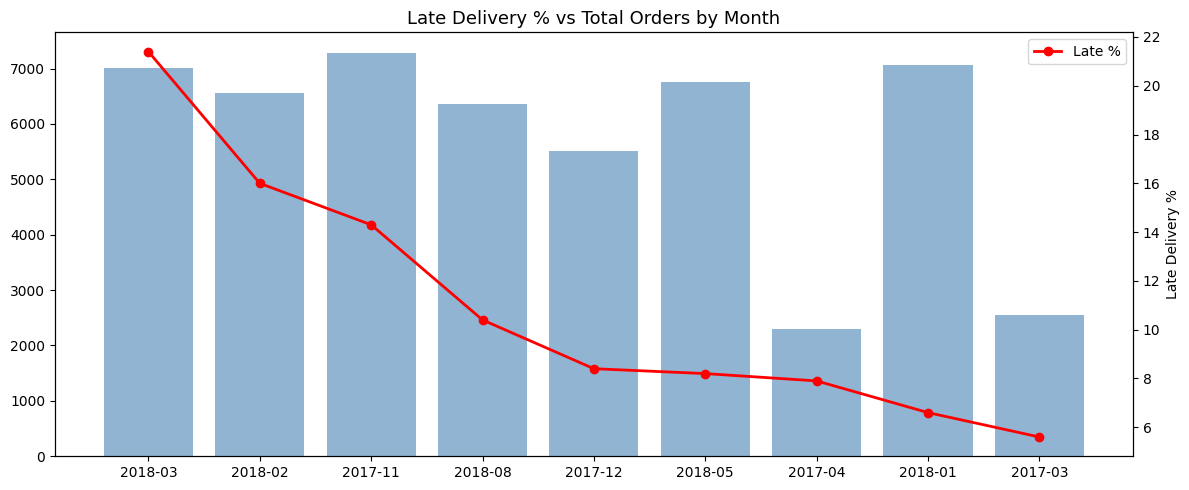

Chart saved!


In [13]:

df3 = df3[df3['total_orders'] > 10]

plt.figure(figsize=(12, 5))

# Bars - total orders
plt.bar(df3['month'], df3['total_orders'],
        color='steelblue', alpha=0.6, label='Total Orders')

# Line - late percentage
ax2 = plt.twinx()
ax2.plot(df3['month'], df3['late_percentage'],
         color='red', linewidth=2, marker='o', label='Late %')

plt.title('Late Delivery % vs Total Orders by Month', fontsize=13)
plt.xticks(rotation=45)
plt.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.set_ylabel('Late Delivery %')
plt.tight_layout()
plt.savefig('story3_delivery.png', dpi=150)
plt.show()
print("Chart saved!")

In [14]:
# RFM Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data load karo
df_rfm = pd.read_csv('RFM of users.csv')

# Recency days clean karo - round off karo
df_rfm['recency_days'] = df_rfm['recency_days'].round(0)

# Customer segments banao
def segment_customer(row):
    if row['recency_days'] <= 90 and row['frequency'] >= 2:
        return 'Champion 🏆'
    elif row['recency_days'] <= 90 and row['frequency'] == 1:
        return 'New Customer 🟢'
    elif row['recency_days'] <= 180 and row['frequency'] >= 2:
        return 'Loyal 💛'
    elif row['recency_days'] > 180 and row['frequency'] >= 2:
        return 'At Risk ⚠️'
    elif row['recency_days'] > 365:
        return 'Lost 🔴'
    else:
        return 'Potential 🔵'

df_rfm['segment'] = df_rfm.apply(segment_customer, axis=1)

# Count karo har segment mein kitne customers
segment_counts = df_rfm['segment'].value_counts()
print(segment_counts)

segment
Lost 🔴            7
Potential 🔵       7
New Customer 🟢    4
At Risk ⚠️        1
Champion 🏆        1
Name: count, dtype: int64


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data load karo
df_rfm = pd.read_csv('rfm_data.csv')

# Recency days clean karo - round off karo
df_rfm['recency_days'] = df_rfm['recency_days'].round(0)


def segment_customer(row):
    if row['recency_days'] <= 90 and row['frequency'] >= 2:
        return 'Champion 🏆'
    elif row['recency_days'] <= 90 and row['frequency'] == 1:
        return 'New Customer 🟢'
    elif row['recency_days'] <= 180 and row['frequency'] >= 2:
        return 'Loyal 💛'
    elif row['recency_days'] > 180 and row['frequency'] >= 2:
        return 'At Risk ⚠️'
    elif row['recency_days'] > 365:
        return 'Lost 🔴'
    else:
        return 'Potential 🔵'

df_rfm['segment'] = df_rfm.apply(segment_customer, axis=1)

# Count karo har segment mein kitne customers
segment_counts = df_rfm['segment'].value_counts()
print(segment_counts)

segment
Potential 🔵       54432
Lost 🔴            24355
New Customer 🟢    11769
At Risk ⚠️         1778
Loyal 💛             626
Champion 🏆          397
Name: count, dtype: int64


/tmp/ipykernel_1878/3344485481.py:38: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1878/3344485481.py:38: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1878/3344485481.py:38: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1878/3344485481.py:38: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1878/3344485481.py:38: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1878/3344485481.py:39: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('story4_rfm_segments.png', dpi=150)
/tmp/ipykernel_1878/3344485481.py:39: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.sa

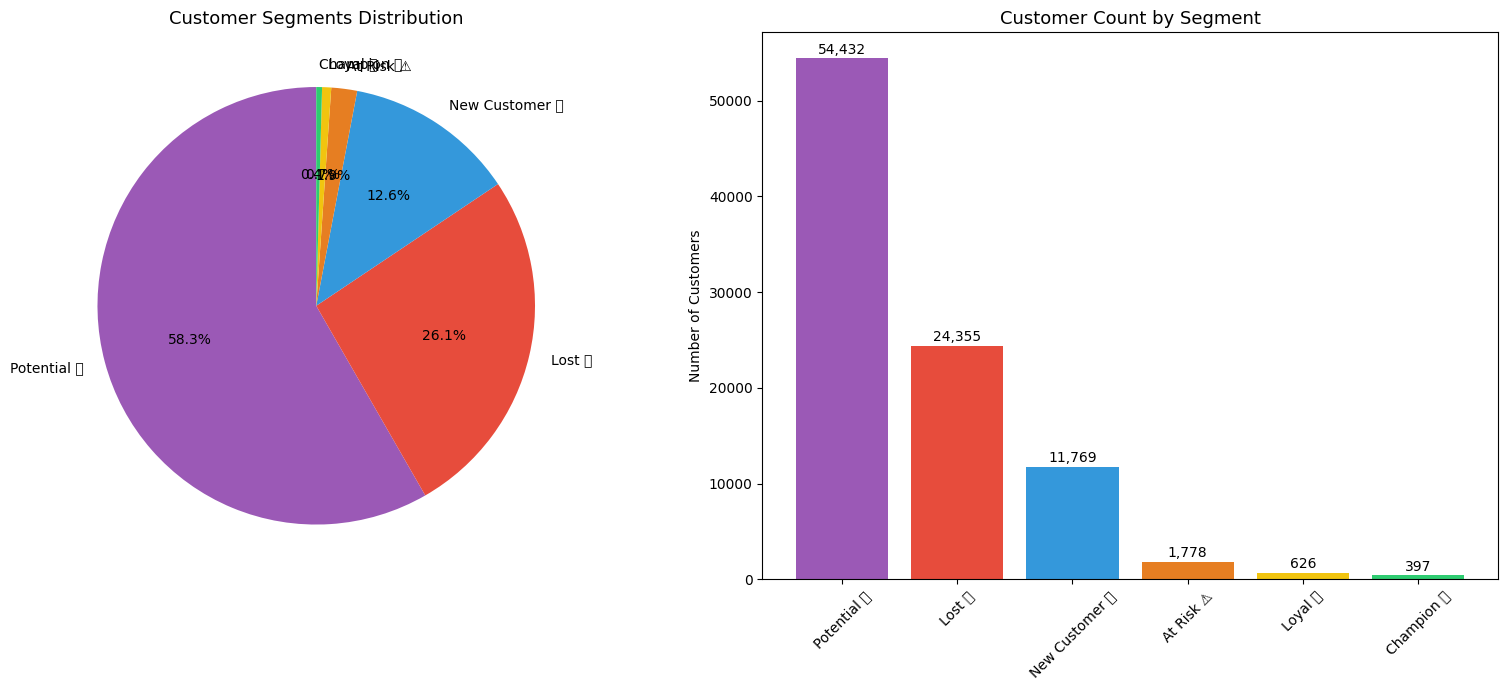

RFM Chart saved!


In [16]:
# RFM Segmentation Charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Colors har segment ke liye
colors = {
    'Champion 🏆': '#2ecc71',
    'Loyal 💛': '#f1c40f',
    'At Risk ⚠️': '#e67e22',
    'Lost 🔴': '#e74c3c',
    'New Customer 🟢': '#3498db',
    'Potential 🔵': '#9b59b6'
}

segment_colors = [colors[s] for s in segment_counts.index]

# Left: Pie chart
ax1.pie(segment_counts.values,
        labels=segment_counts.index,
        colors=segment_colors,
        autopct='%1.1f%%',
        startangle=90)
ax1.set_title('Customer Segments Distribution', fontsize=13)

# Right: Bar chart
bars = ax2.bar(segment_counts.index,
               segment_counts.values,
               color=segment_colors)
ax2.set_title('Customer Count by Segment', fontsize=13)
ax2.set_ylabel('Number of Customers')
ax2.tick_params(axis='x', rotation=45)

# Numbers bar ke upar dikhao
for bar, val in zip(bars, segment_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('story4_rfm_segments.png', dpi=150)
plt.show()
print("RFM Chart saved!")